# EDA 3 Analysis

Notebook version of the analysis with plots displayed inline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

DATA_FILE = Path("EDA3.csv")
TARGET_VAR = "Strength"
X_VAR = "Age"
Y_VAR = "Strength"

In [2]:
df = pd.read_csv(DATA_FILE)

### 1. GENERAL OVERVIEW

In [ ]:

print("\nShape:")
print(df.shape)

print("\nHead of dataset:")
display(df.head())

1. GENERAL OVERVIEW

Shape:
(60, 7)

Head of dataset:


,ID,Age,AgeGroupBeginExclusive,AgeGroupEndInclusive,Strength,Sex,Party
0,1,27,21,42,26,F,Rep
1,2,58,42,62,22,F,Rep
2,3,32,21,42,29,F,Dem
3,4,51,42,62,18,F,Dem
4,5,38,21,42,28,F,Rep


In [5]:
print("\nInfo:")
df.info()


Info:
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   ID                      60 non-null     int64
 1   Age                     60 non-null     int64
 2   AgeGroupBeginExclusive  60 non-null     int64
 3   AgeGroupEndInclusive    60 non-null     int64
 4   Strength                60 non-null     int64
 5   Sex                     60 non-null     str  
 6   Party                   60 non-null     str  
dtypes: int64(5), str(2)
memory usage: 3.4 KB


In [7]:

print("\nDescribe (numeric columns):")
display(df.describe())


Describe (numeric columns):


,ID,Age,AgeGroupBeginExclusive,AgeGroupEndInclusive,Strength
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,53.000000,43.000000,63.333333,19.583333
std,17.464249,17.458911,17.640477,17.219093,5.636719
min,1.000000,22.000000,21.000000,42.000000,9.000000
25%,15.750000,37.500000,21.000000,42.000000,16.000000
50%,30.500000,55.500000,42.000000,62.000000,20.000000
75%,45.250000,66.000000,62.000000,82.000000,23.000000
max,60.000000,82.000000,62.000000,82.000000,35.000000


In [9]:
print("\nCount of each category in Sex:")
print("Non-null count:", df["Sex"].count())
display(df["Sex"].value_counts())

print("\nCount of each category in Party:")
print("Non-null count:", df["Party"].count())
display(df["Party"].value_counts())


Count of each category in Sex:
Non-null count: 60


Sex
F    36
M    24
Name: count, dtype: int64


Count of each category in Party:
Non-null count: 60


Party
Rep    34
Dem    26
Name: count, dtype: int64

In [11]:

print(f"\nDrop NA example for {TARGET_VAR}:")
display(df[TARGET_VAR].dropna())



Drop NA example for Strength:


0     26
1     22
2     29
3     18
4     28
5     10
6     27
7     17
8     24
9     22
10    16
11     9
12    24
13    23
14    20
15    16
16    26
17    22
18    20
19    18
20    25
21    20
22    23
23    21
24    22
25    22
26    16
27    12
28    16
29    35
30    18
31    20
32    13
33    21
34    12
35    16
36    30
37    12
38    23
39    25
40    13
41    16
42     9
43    22
44    11
45    27
46    18
47    19
48    11
49    18
50    16
51    18
52    15
53    16
54    18
55    24
56    28
57    23
58    14
59    20
Name: Strength, dtype: int64

In [12]:

print("\nStatistics per group:")
print("Average strength by party:")
display(df.groupby("Party")[TARGET_VAR].mean())
print("\nAverage strength by sex and party:")
display(df.groupby(["Sex", "Party"])[TARGET_VAR].mean())


Statistics per group:
Average strength by party:


Party
Dem    18.307692
Rep    20.558824
Name: Strength, dtype: float64


Average strength by sex and party:


Sex  Party
F    Dem      20.375000
     Rep      20.050000
M    Dem      15.000000
     Rep      21.285714
Name: Strength, dtype: float64

### 2. DISTRIBUTION ANALYSIS FOR Strength

In [24]:
series = df[TARGET_VAR].dropna()

print("Min:", series.min())
print("Max:", series.max())
print("Mean:", series.mean())
print("Median:", series.median())
print("Variance:", series.var())
print("Standard deviation:", series.std())
print("Range:", series.max() - series.min())
print("Interquartile range:", series.quantile(0.75) - series.quantile(0.25))

Min: 9
Max: 35
Mean: 19.583333333333332
Median: 20.0
Variance: 31.772598870056495
Standard deviation: 5.63671880352892
Range: 26
Interquartile range: 7.0


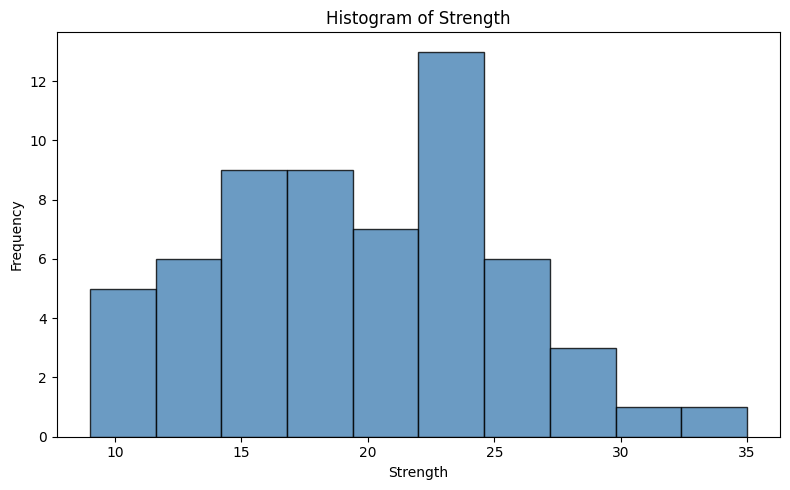

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(series, bins=10, color="steelblue", edgecolor="black", alpha=0.8)
plt.title("Histogram of Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

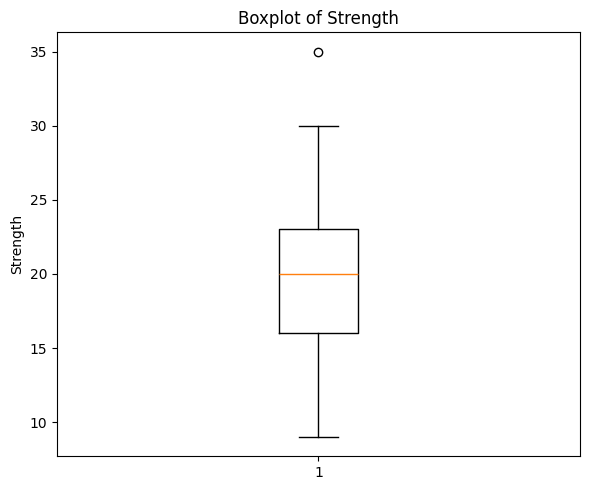

In [15]:
plt.figure(figsize=(6, 5))
plt.boxplot(series)
plt.title("Boxplot of Strength")
plt.ylabel("Strength")
plt.tight_layout()
plt.show()

### 3. COVARIANCE AND CORRELATION BETWEEN Age AND Strength

In [ ]:
pair_df = df[[X_VAR, Y_VAR]].dropna()

print("\nCovariance matrix:")
display(pair_df.cov())

print("\nCorrelation matrix:")
corr_matrix = pair_df.corr()
display(corr_matrix)

corr_coef, p_value = pearsonr(pair_df[X_VAR], pair_df[Y_VAR])
print(f"\nPearson correlation coefficient between {X_VAR} and {Y_VAR}: {corr_coef}")
print("P-value:", p_value)


3. COVARIANCE AND CORRELATION BETWEEN Age AND Strength

Covariance matrix:


,Age,Strength
Age,304.813559,-85.406780
Strength,-85.406780,31.772599



Correlation matrix:


,Age,Strength
Age,1.000000,-0.867858
Strength,-0.867858,1.000000



Pearson correlation coefficient between Age and Strength: -0.8678583287144029
P-value: 2.862146420494477e-19


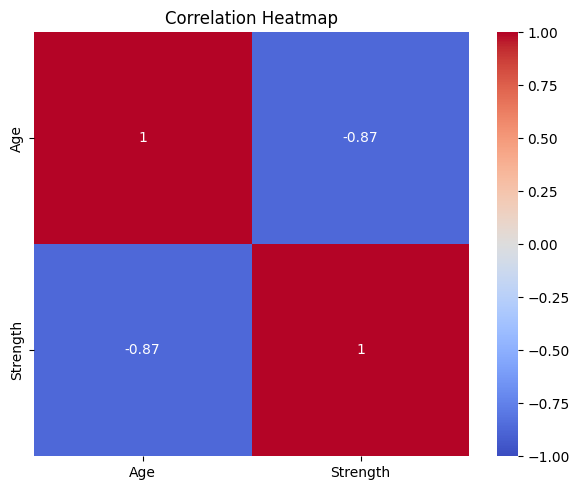

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

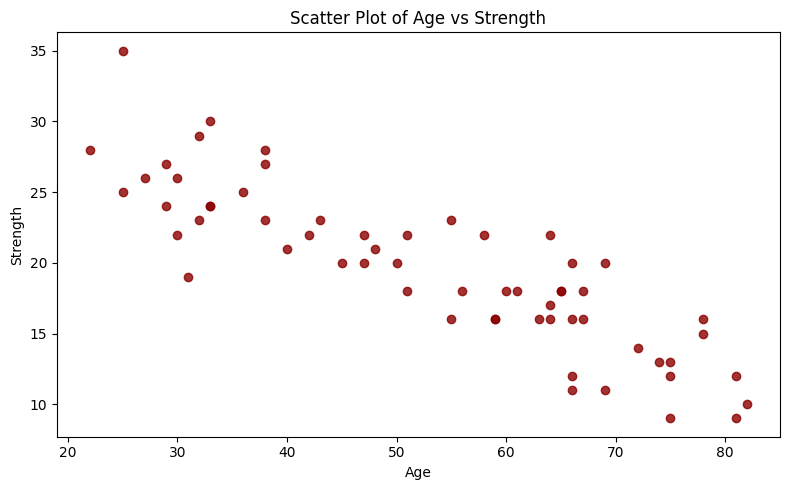

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(pair_df[X_VAR], pair_df[Y_VAR], color="darkred", alpha=0.8)
plt.title("Scatter Plot of Age vs Strength")
plt.xlabel("Age")
plt.ylabel("Strength")
plt.tight_layout()
plt.show()